# Week 2 & 3 Homework: Project Dataset Preprocessing and Feature Engineering (FinMark)

## Objective
Transform FinMark’s raw customer, product, and transaction datasets into clean, structured, and feature-rich datasets suitable for predicting customer purchase behaviour.

## Datasets Used
- `transactions_data.csv` (transaction-level purchase records)
- `products_data.csv` (product reference table)
- `customers_data.csv` (customer/company reference table)

## Tools / Libraries
- pandas, numpy (data handling)
- matplotlib, seaborn (EDA + visuals)

In [2]:
import os
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

## Step 1: Load Datasets + Validate

We load the three datasets into pandas DataFrames and validate:
- shape (rows/columns)
- column names
- preview of records
- basic summary statistics

In [6]:
import pandas as pd
from pathlib import Path

# Notebook folder
NOTEBOOK_DIR = Path.cwd()
print("Notebook current folder:", NOTEBOOK_DIR)

# Go up to the parent folder, then into /data
DATA_DIR = NOTEBOOK_DIR.parent / "data"
print("Data folder resolved to:", DATA_DIR)

TRANSACTIONS_PATH = DATA_DIR / "transactions_data.csv"
PRODUCTS_PATH     = DATA_DIR / "products_data.csv"
CUSTOMERS_PATH    = DATA_DIR / "customers_data.csv"

print("Exists?")
print("transactions:", TRANSACTIONS_PATH.exists())
print("products:", PRODUCTS_PATH.exists())
print("customers:", CUSTOMERS_PATH.exists())

transactions = pd.read_csv(TRANSACTIONS_PATH)
products = pd.read_csv(PRODUCTS_PATH)
customers = pd.read_csv(CUSTOMERS_PATH)

print("Loaded shapes:")
print("transactions:", transactions.shape)
print("products:", products.shape)
print("customers:", customers.shape)

transactions.head()


Notebook current folder: /Users/tris/2025 Developments/Machine Learning and Predictive Analysis/MO-IT134 Homework Week 3 Homework Project Dataset Preprocessing and Feature Engineering A3101 Atienza T.
Data folder resolved to: /Users/tris/2025 Developments/Machine Learning and Predictive Analysis/data
Exists?
transactions: True
products: True
customers: True
Loaded shapes:
transactions: (10000, 8)
products: (20, 3)
customers: (100, 4)


,Unnamed: 0,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price,Total_Cost
0,0.0,1.0,88.0,6.0,NaN,2024/03/26,194379.147964,1075200.0
1,1.0,2.0,29.0,19.0,16.0,"July 09, 2024",97930.993380,1428000.0
2,2.0,NaN,28.0,18.0,6.0,04/13/2024,126095.547778,940800.0
3,3.0,4.0,85.0,12.0,12.0,09-06-2023,NaN,1008000.0
4,4.0,5.0,47.0,3.0,8.0,07/06/2021,99575.609634,705600.0


In [ ]:
for name, df in [("transactions", transactions), ("products", products), ("customers", customers)]:
    print(f"\n--- {name.upper()} ---")
    print(df.info())
    display(df.head(3))

In [7]:
transactions.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,9000.0,NaN,NaN,NaN,4994.049111,2885.331476,0.0,2501.75,4997.5,7477.25,9999.0
Transaction_ID,9000.0,NaN,NaN,NaN,5005.177556,2894.971964,1.0,2491.75,5005.0,7527.25,9999.0
Company_ID,9000.0,NaN,NaN,NaN,50.583556,28.90087,1.0,25.0,50.0,76.0,100.0
Product_ID,9000.0,NaN,NaN,NaN,10.446778,5.768341,1.0,5.0,10.0,15.0,20.0
Quantity,9000.0,NaN,NaN,NaN,10.528778,5.808062,0.0,6.0,11.0,16.0,21.0
Transaction_Date,10000,4812,2021/02/21,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Price,9000.0,NaN,NaN,NaN,134652.802537,39058.106978,75613.362923,100686.369472,131297.783516,162221.485713,246279.050335
Total_Cost,9000.0,NaN,NaN,NaN,1424246.133333,908627.390842,84000.0,672000.0,1344000.0,1965600.0,4480000.0


## Step 2: Exploratory Data Analysis (EDA)

We examine:
- Missing values
- Outliers / inconsistent entries
- Incorrect or mixed data types
- Redundant or irrelevant columns

This EDA will guide preprocessing decisions.

In [14]:
#Missing values summary

def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    rep = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().sum() / len(df) * 100).round(2),
        "dtype": df.dtypes.astype(str)
    })
    return rep.sort_values("missing_pct", ascending=False)

display(missing_report(transactions))
display(missing_report(products))
display(missing_report(customers))

,missing_count,missing_pct,dtype
Unnamed: 0,1000,10.0,float64
Transaction_ID,1000,10.0,float64
Company_ID,1000,10.0,float64
Product_ID,1000,10.0,float64
Quantity,1000,10.0,float64
Product_Price,1000,10.0,float64
Total_Cost,1000,10.0,float64
Transaction_Date,0,0.0,object


,missing_count,missing_pct,dtype
Product_ID,2,10.0,float64
Product_Name,0,0.0,object
Product_Price,0,0.0,object


,missing_count,missing_pct,dtype
Company_Profit,12,12.0,float64
Company_ID,10,10.0,float64
Company_Name,0,0.0,object
Address,0,0.0,object


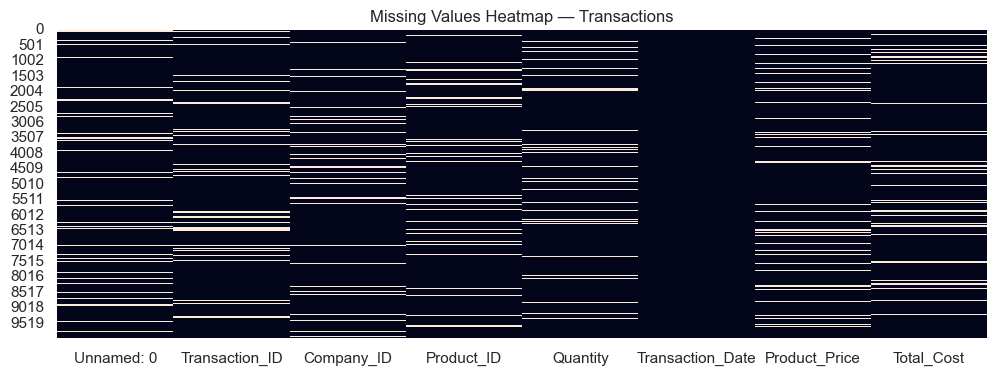

In [15]:
#Visualise missingness

plt.figure(figsize=(12, 4))
sns.heatmap(transactions.isna(), cbar=False)
plt.title("Missing Values Heatmap — Transactions")
plt.show()

In [16]:
#Check mixed date formats

transactions["Transaction_Date"].head(10)

0          2024/03/26
1       July 09, 2024
2          04/13/2024
3          09-06-2023
4          07/06/2021
5          2021/07/12
6          2023/11/01
7    October 31, 2023
8          25-02-2024
9          29-03-2021
Name: Transaction_Date, dtype: object

In [17]:
#Outliers quick scan

num_cols = [c for c in transactions.columns if c.lower() not in ["transaction_date"] and transactions[c].dtype != "object"]
transactions[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,9000.0,4.994049e+03,2885.331476,0.000000,2501.750000,4.997500e+03,7.477250e+03,9.999000e+03
Transaction_ID,9000.0,5.005178e+03,2894.971964,1.000000,2491.750000,5.005000e+03,7.527250e+03,9.999000e+03
Company_ID,9000.0,5.058356e+01,28.900870,1.000000,25.000000,5.000000e+01,7.600000e+01,1.000000e+02
Product_ID,9000.0,1.044678e+01,5.768341,1.000000,5.000000,1.000000e+01,1.500000e+01,2.000000e+01
Quantity,9000.0,1.052878e+01,5.808062,0.000000,6.000000,1.100000e+01,1.600000e+01,2.100000e+01
Product_Price,9000.0,1.346528e+05,39058.106978,75613.362923,100686.369472,1.312978e+05,1.622215e+05,2.462791e+05
Total_Cost,9000.0,1.424246e+06,908627.390842,84000.000000,672000.000000,1.344000e+06,1.965600e+06,4.480000e+06


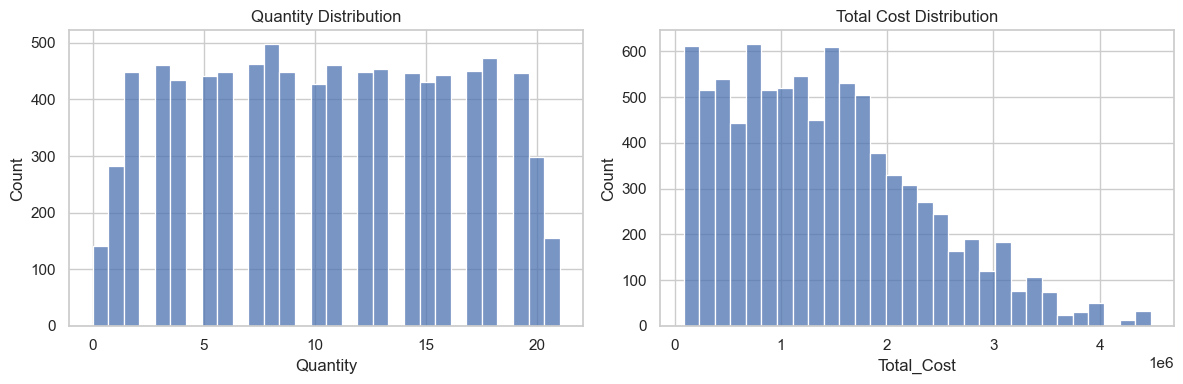

In [18]:
#Distribution plots

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(transactions["Quantity"], bins=30, ax=axes[0])
axes[0].set_title("Quantity Distribution")

sns.histplot(transactions["Total_Cost"], bins=30, ax=axes[1])
axes[1].set_title("Total Cost Distribution")

plt.tight_layout()
plt.show()

## Step 3: Preprocessing Decisions (Based on EDA)

### Transactions
- Drop redundant index-like column (e.g., `Unnamed: 0`)
- Standardise ID columns to integer where possible
- Parse `Transaction_Date` into datetime (handles mixed formats)
- Handle missing critical fields:
  - Drop rows missing `Company_ID` or `Product_ID` (cannot join / model)
  - Impute missing `Product_Price` using `products_data` reference prices
  - Recompute or fill `Total_Cost` using `Quantity * Product_Price` when missing
- Remove obvious invalid values (e.g., negative quantities/cost)

### Products
- Clean currency-format `Product_Price` into numeric
- Drop rows missing `Product_ID`

### Customers
- Drop rows missing `Company_ID`
- Impute missing `Company_Profit` using median
- Extract a simple `City` feature from Address

## Step 4: Clean Products Dataset
We convert product price strings (e.g., "?140,000") into numeric and ensure `Product_ID` is valid.

In [20]:
products_clean = products.copy()

# Drop rows with missing Product_ID (cannot reliably join)
products_clean = products_clean.dropna(subset=["Product_ID"])

# Convert Product_ID to int
products_clean["Product_ID"] = products_clean["Product_ID"].astype(int)

# Clean Product_Price: remove non-numeric chars except comma/dot, then convert
def clean_currency_to_float(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    s = re.sub(r"[^0-9.,]", "", s)  # keep digits, comma, dot
    s = s.replace(",", "")
    return float(s) if s != "" else np.nan

products_clean["Product_Price"] = products_clean["Product_Price"].apply(clean_currency_to_float)

# Check
display(products_clean.head())
products_clean.info()

,Product_ID,Product_Name,Product_Price
0,1,FinPredictor Suite,140000.0
1,2,MarketMinder Analytics,168000.0
2,3,TrendWise Forecaster,100800.0
3,4,CustomerScope Insights,123200.0
4,5,SalesSync Optimizer,84000.0


<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 0 to 19
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     18 non-null     int64  
 1   Product_Name   18 non-null     object 
 2   Product_Price  18 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 576.0+ bytes


## Step 5: Clean Customers Dataset
We fix missing IDs, handle missing profits, and extract a basic location feature from Address.

In [22]:
customers_clean = customers.copy()

# Drop rows missing Company_ID
customers_clean = customers_clean.dropna(subset=["Company_ID"])

# Convert Company_ID to int
customers_clean["Company_ID"] = customers_clean["Company_ID"].astype(int)

# Impute missing Company_Profit (median)
profit_median = customers_clean["Company_Profit"].median()
customers_clean["Company_Profit"] = customers_clean["Company_Profit"].fillna(profit_median)

# Extract City from Address (assumes "... , City, Philippines")
def extract_city(address):
    if pd.isna(address):
        return np.nan
    parts = [p.strip() for p in str(address).split(",")]
    # Usually: Street, Barangay, City, Philippines -> city is second to last
    if len(parts) >= 2:
        return parts[-2]
    return np.nan

customers_clean["City"] = customers_clean["Address"].apply(extract_city)

# Optional: log profit (helps with skew)
customers_clean["Company_Profit_Log"] = np.log1p(customers_clean["Company_Profit"])

display(customers_clean.head())
customers_clean.info()


,Company_ID,Company_Name,Company_Profit,Address,City,Company_Profit_Log
0,1,Tech Enterprises 1,80701.0,"EDSA, Barangay 606, Pasig, Philippines",Pasig,11.298519
1,2,Global Partners 2,80511.0,"Commonwealth Ave, Barangay 789, Taguig, Philip...",Taguig,11.296162
2,3,Quantum Associates 3,110664.0,"Roxas Blvd, Barangay 505, Pasig, Philippines",Pasig,11.614263
3,4,Prime Network 4,74653.0,"Alabang-Zapote Rd, Barangay 202, Taguig, Phili...",Taguig,11.220619
4,5,Elite Ventures 5,69427.0,"Ayala Avenue, Barangay 101, Makati, Philippines",Makati,11.148046


<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, 0 to 99
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Company_ID          90 non-null     int64  
 1   Company_Name        90 non-null     object 
 2   Company_Profit      90 non-null     float64
 3   Address             90 non-null     object 
 4   City                90 non-null     object 
 5   Company_Profit_Log  90 non-null     float64
dtypes: float64(2), int64(1), object(3)
memory usage: 4.9+ KB


## Step 6: Clean Transactions Dataset
We:
- drop redundant index column
- standardise IDs
- parse mixed-format dates into datetime
- impute missing prices using the products reference table
- recompute/fill Total_Cost where possible
- drop rows missing key join fields (Company_ID, Product_ID)

In [32]:
transactions_clean = transactions.copy()

# Drop redundant index-like column if present
if "Unnamed: 0" in transactions_clean.columns:
    transactions_clean = transactions_clean.drop(columns=["Unnamed: 0"])

transactions_clean["Transaction_Date"] = pd.to_datetime(
    transactions_clean["Transaction_Date"],
    errors="coerce"
)

# Drop rows where date could not be parsed (optional but recommended for time features)
transactions_clean = transactions_clean.dropna(subset=["Transaction_Date"])

# Drop rows missing key IDs needed for joins
transactions_clean = transactions_clean.dropna(subset=["Company_ID", "Product_ID"])

# Convert IDs to int
transactions_clean["Company_ID"] = transactions_clean["Company_ID"].astype(int)
transactions_clean["Product_ID"] = transactions_clean["Product_ID"].astype(int)

# Quantity: must be positive; drop invalid or missing
transactions_clean["Quantity"] = pd.to_numeric(transactions_clean["Quantity"], errors="coerce")
transactions_clean = transactions_clean.dropna(subset=["Quantity"])
transactions_clean = transactions_clean[transactions_clean["Quantity"] > 0]

# Merge product price reference
transactions_clean = transactions_clean.merge(
    products_clean[["Product_ID", "Product_Price", "Product_Name"]],
    on="Product_ID",
    how="left",
    suffixes=("", "_ref")
)

# If transaction Product_Price missing, fill using reference price
if "Product_Price" in transactions_clean.columns:
    transactions_clean["Product_Price"] = pd.to_numeric(transactions_clean["Product_Price"], errors="coerce")
    transactions_clean["Product_Price"] = transactions_clean["Product_Price"].fillna(transactions_clean["Product_Price_ref"])
else:
    transactions_clean["Product_Price"] = transactions_clean["Product_Price_ref"]

# Total_Cost: recompute if missing or inconsistent
transactions_clean["Total_Cost"] = pd.to_numeric(transactions_clean["Total_Cost"], errors="coerce")

# Compute expected cost
transactions_clean["Expected_Total_Cost"] = transactions_clean["Quantity"] * transactions_clean["Product_Price"]

# Fill missing Total_Cost with expected value
transactions_clean["Total_Cost"] = transactions_clean["Total_Cost"].fillna(transactions_clean["Expected_Total_Cost"])

# Optional: If Total_Cost exists but is far from expected, replace (handles inconsistencies)
diff_ratio = (transactions_clean["Total_Cost"] - transactions_clean["Expected_Total_Cost"]).abs() / transactions_clean["Expected_Total_Cost"].replace(0, np.nan)
transactions_clean.loc[diff_ratio > 0.20, "Total_Cost"] = transactions_clean.loc[diff_ratio > 0.20, "Expected_Total_Cost"]

# Clean up helper cols
transactions_clean = transactions_clean.drop(columns=["Product_Price_ref", "Expected_Total_Cost"], errors="ignore")

transactions_clean.head()


,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price,Total_Cost,Product_Name
0,6.0,80,11,4.0,2021-07-12,160658.675350,627200.0,OptiFlow Automation
1,NaN,57,10,6.0,2022-07-10,89600.000000,627200.0,SegmentX Targeting
2,24.0,70,1,19.0,2021-05-03,145162.097359,2660000.0,FinPredictor Suite
3,34.0,92,8,11.0,2024-02-27,141578.710506,1814400.0,NaN
4,36.0,71,20,3.0,2022-05-19,224000.000000,672000.0,FinSphere Intelligence Suite


In [24]:
print("Clean transactions shape:", transactions_clean.shape)
display(missing_report(transactions_clean))
transactions_clean.describe().T

Clean transactions shape: (1802, 8)


,missing_count,missing_pct,dtype
Product_Name,180,9.99,object
Transaction_ID,168,9.32,float64
Product_Price,22,1.22,float64
Total_Cost,5,0.28,float64
Company_ID,0,0.00,int64
Product_ID,0,0.00,int64
Quantity,0,0.00,float64
Transaction_Date,0,0.00,datetime64[ns]


,count,mean,min,25%,50%,75%,max,std
Transaction_ID,1634.0,5116.876377,6.0,2656.75,5210.5,7613.25,9997.0,2871.065978
Company_ID,1802.0,50.880133,1.0,25.0,51.0,76.0,100.0,28.876617
Product_ID,1802.0,10.335738,1.0,5.0,10.0,15.0,20.0,5.749629
Quantity,1802.0,10.825749,1.0,6.0,11.0,16.0,21.0,5.647978
Transaction_Date,1802,2022-10-14 20:17:02.863484928,2020-10-30 00:00:00,2021-10-16 00:00:00,2022-10-18 00:00:00,2023-10-05 18:00:00,2024-10-28 00:00:00,NaN
Product_Price,1780.0,135287.219325,75980.389673,100800.0,133438.798252,162414.266883,246276.227761,39063.432436
Total_Cost,1797.0,1465147.974846,78909.525427,716800.0,1360800.0,2016000.0,4480000.0,912685.685961


## Step 7: Feature Engineering

We will engineer meaningful features for predicting purchase behaviour.

### Transaction-level time features
- Year, Month, DayOfWeek
- Is_Weekend

### Customer/Company-level aggregated features (RFM-style)
- Frequency: total transactions
- Recency: days since last purchase
- Monetary: total spend, avg order value
- Product diversity: unique products purchased
- Volume: total quantity, avg quantity per transaction

### Merge Customer reference features
- Company_Profit, Company_Profit_Log
- City (categorical feature)

In [34]:
df = transactions_clean.copy()

df["Year"] = df["Transaction_Date"].dt.year
df["Month"] = df["Transaction_Date"].dt.month
df["DayOfWeek"] = df["Transaction_Date"].dt.dayofweek  # Mon=0
df["Is_Weekend"] = (df["DayOfWeek"] >= 5).astype(int)

df.head()

,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price,Total_Cost,Product_Name,Year,Month,DayOfWeek,Is_Weekend
0,6.0,80,11,4.0,2021-07-12,160658.675350,627200.0,OptiFlow Automation,2021,7,0,0
1,NaN,57,10,6.0,2022-07-10,89600.000000,627200.0,SegmentX Targeting,2022,7,6,1
2,24.0,70,1,19.0,2021-05-03,145162.097359,2660000.0,FinPredictor Suite,2021,5,0,0
3,34.0,92,8,11.0,2024-02-27,141578.710506,1814400.0,NaN,2024,2,1,0
4,36.0,71,20,3.0,2022-05-19,224000.000000,672000.0,FinSphere Intelligence Suite,2022,5,3,0


In [35]:
# Reference date for recency (latest transaction date in dataset)
reference_date = df["Transaction_Date"].max()

company_features = df.groupby("Company_ID").agg(
    total_transactions=("Transaction_Date", "count"),
    total_quantity=("Quantity", "sum"),
    avg_quantity=("Quantity", "mean"),
    total_spend=("Total_Cost", "sum"),
    avg_order_value=("Total_Cost", "mean"),
    unique_products=("Product_ID", "nunique"),
    last_purchase_date=("Transaction_Date", "max"),
    first_purchase_date=("Transaction_Date", "min"),
).reset_index()

company_features["recency_days"] = (reference_date - company_features["last_purchase_date"]).dt.days
company_features["tenure_days"] = (reference_date - company_features["first_purchase_date"]).dt.days

# Optional: purchases per month approximation (frequency normalised)
company_features["txn_per_30days"] = company_features["total_transactions"] / (company_features["tenure_days"].replace(0, np.nan) / 30)
company_features["txn_per_30days"] = company_features["txn_per_30days"].fillna(company_features["total_transactions"])

company_features.head()

,Company_ID,total_transactions,total_quantity,avg_quantity,total_spend,avg_order_value,unique_products,last_purchase_date,first_purchase_date,recency_days,tenure_days,txn_per_30days
0,1,12,135.0,11.250000,1.838260e+07,1.531883e+06,9,2024-07-10,2020-12-08,110,1420,0.253521
1,2,19,183.0,9.631579,2.614494e+07,1.376049e+06,10,2024-08-14,2021-01-15,75,1382,0.412446
2,3,15,184.0,12.266667,2.614969e+07,1.743312e+06,10,2024-07-01,2020-12-23,119,1405,0.320285
3,4,22,218.0,9.909091,3.272394e+07,1.487452e+06,16,2024-07-26,2020-12-17,94,1411,0.467753
4,5,9,82.0,9.111111,1.118493e+07,1.242770e+06,8,2024-10-25,2020-11-27,3,1431,0.188679


In [36]:
feature_table = company_features.merge(
    customers_clean[["Company_ID", "Company_Name", "Company_Profit", "Company_Profit_Log", "City"]],
    on="Company_ID",
    how="left"
)

feature_table.head()

,Company_ID,total_transactions,total_quantity,avg_quantity,total_spend,avg_order_value,unique_products,last_purchase_date,first_purchase_date,recency_days,tenure_days,txn_per_30days,Company_Name,Company_Profit,Company_Profit_Log,City
0,1,12,135.0,11.250000,1.838260e+07,1.531883e+06,9,2024-07-10,2020-12-08,110,1420,0.253521,Tech Enterprises 1,80701.0,11.298519,Pasig
1,2,19,183.0,9.631579,2.614494e+07,1.376049e+06,10,2024-08-14,2021-01-15,75,1382,0.412446,Global Partners 2,80511.0,11.296162,Taguig
2,3,15,184.0,12.266667,2.614969e+07,1.743312e+06,10,2024-07-01,2020-12-23,119,1405,0.320285,Quantum Associates 3,110664.0,11.614263,Pasig
3,4,22,218.0,9.909091,3.272394e+07,1.487452e+06,16,2024-07-26,2020-12-17,94,1411,0.467753,Prime Network 4,74653.0,11.220619,Taguig
4,5,9,82.0,9.111111,1.118493e+07,1.242770e+06,8,2024-10-25,2020-11-27,3,1431,0.188679,Elite Ventures 5,69427.0,11.148046,Makati


In [37]:
# Example: Most purchased product category proxy (here: product name)
top_product = df.groupby(["Company_ID", "Product_Name"])["Quantity"].sum().reset_index()
top_product = top_product.sort_values(["Company_ID", "Quantity"], ascending=[True, False])
top_product = top_product.drop_duplicates("Company_ID").rename(columns={"Product_Name": "Top_Product"})

feature_table = feature_table.merge(top_product[["Company_ID", "Top_Product"]], on="Company_ID", how="left")

feature_table.head()

,Company_ID,total_transactions,total_quantity,avg_quantity,total_spend,avg_order_value,unique_products,last_purchase_date,first_purchase_date,recency_days,tenure_days,txn_per_30days,Company_Name,Company_Profit,Company_Profit_Log,City,Top_Product
0,1,12,135.0,11.250000,1.838260e+07,1.531883e+06,9,2024-07-10,2020-12-08,110,1420,0.253521,Tech Enterprises 1,80701.0,11.298519,Pasig,DataBridge Integration Tool
1,2,19,183.0,9.631579,2.614494e+07,1.376049e+06,10,2024-08-14,2021-01-15,75,1382,0.412446,Global Partners 2,80511.0,11.296162,Taguig,EcoNomix Modeler
2,3,15,184.0,12.266667,2.614969e+07,1.743312e+06,10,2024-07-01,2020-12-23,119,1405,0.320285,Quantum Associates 3,110664.0,11.614263,Pasig,InsightMax Insights Platform
3,4,22,218.0,9.909091,3.272394e+07,1.487452e+06,16,2024-07-26,2020-12-17,94,1411,0.467753,Prime Network 4,74653.0,11.220619,Taguig,RevenueVue Dashboard
4,5,9,82.0,9.111111,1.118493e+07,1.242770e+06,8,2024-10-25,2020-11-27,3,1431,0.188679,Elite Ventures 5,69427.0,11.148046,Makati,CustomerScope Insights


## Step 8: Validate Engineered Features
We inspect distributions and check for extreme values.

In [38]:
feature_table.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Company_ID,100.0,NaN,NaN,NaN,50.5,1.0,25.75,50.5,75.25,100.0,29.011492
total_transactions,100.0,NaN,NaN,NaN,18.02,7.0,15.0,18.0,21.0,30.0,4.259226
total_quantity,100.0,NaN,NaN,NaN,195.08,56.0,167.0,201.0,229.0,348.0,52.561398
avg_quantity,100.0,NaN,NaN,NaN,10.796964,5.6,10.0,10.922969,11.6125,14.466667,1.520064
total_spend,100.0,NaN,NaN,NaN,26328709.107987,6525397.118849,20940494.820879,27400223.501356,31095546.173141,47937819.693971,7527720.777855
avg_order_value,100.0,NaN,NaN,NaN,1457005.547844,777827.406915,1332918.230997,1471744.33398,1601185.180051,2223937.374722,243146.90483
unique_products,100.0,NaN,NaN,NaN,11.74,6.0,11.0,12.0,13.0,17.0,2.190982
last_purchase_date,100,NaN,NaN,NaN,2024-07-29 19:40:48,2023-12-11 00:00:00,2024-06-22 18:00:00,2024-08-18 00:00:00,2024-09-26 06:00:00,2024-10-28 00:00:00,NaN
first_purchase_date,100,NaN,NaN,NaN,2021-01-04 07:40:48,2020-10-30 00:00:00,2020-11-22 18:00:00,2020-12-17 00:00:00,2021-01-30 12:00:00,2021-08-23 00:00:00,NaN
recency_days,100.0,NaN,NaN,NaN,90.18,0.0,31.75,71.0,127.25,322.0,77.577381


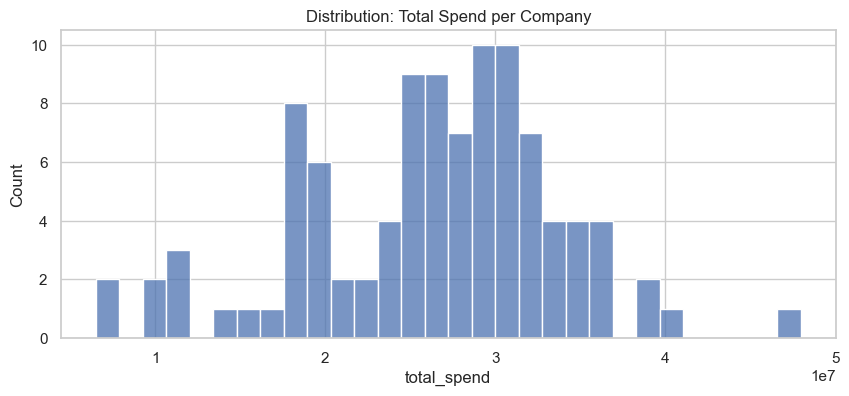

In [39]:
plt.figure(figsize=(10, 4))
sns.histplot(feature_table["total_spend"], bins=30)
plt.title("Distribution: Total Spend per Company")
plt.show()

## Step 9: Save Outputs

We export:
1. Cleaned Transactions (transaction-level)
2. Cleaned Customers
3. Cleaned Products
4. Engineered Feature Table (company-level features)

In [41]:
import os
from pathlib import Path

# Save outputs beside the notebook (recommended for GitHub)
OUTPUT_DIR = Path.cwd() / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

transactions_clean.to_csv(OUTPUT_DIR / "finmark_clean_transactions.csv", index=False)
customers_clean.to_csv(OUTPUT_DIR / "finmark_clean_customers.csv", index=False)
products_clean.to_csv(OUTPUT_DIR / "finmark_clean_products.csv", index=False)
feature_table.to_csv(OUTPUT_DIR / "finmark_engineered_company_features.csv", index=False)

print("Saved files to:", OUTPUT_DIR)
list(OUTPUT_DIR.iterdir())

Saved files to: /Users/tris/2025 Developments/Machine Learning and Predictive Analysis/MO-IT134 Homework Week 3 Homework Project Dataset Preprocessing and Feature Engineering A3101 Atienza T./data/processed


[PosixPath('/Users/tris/2025 Developments/Machine Learning and Predictive Analysis/MO-IT134 Homework Week 3 Homework Project Dataset Preprocessing and Feature Engineering A3101 Atienza T./data/processed/finmark_clean_transactions.csv'),
 PosixPath('/Users/tris/2025 Developments/Machine Learning and Predictive Analysis/MO-IT134 Homework Week 3 Homework Project Dataset Preprocessing and Feature Engineering A3101 Atienza T./data/processed/finmark_clean_customers.csv'),
 PosixPath('/Users/tris/2025 Developments/Machine Learning and Predictive Analysis/MO-IT134 Homework Week 3 Homework Project Dataset Preprocessing and Feature Engineering A3101 Atienza T./data/processed/finmark_engineered_company_features.csv'),
 PosixPath('/Users/tris/2025 Developments/Machine Learning and Predictive Analysis/MO-IT134 Homework Week 3 Homework Project Dataset Preprocessing and Feature Engineering A3101 Atienza T./data/processed/finmark_clean_products.csv')]

## Step 10: Insights, Challenges, and Decisions (Team Discussion)

### Key Insights from EDA
- Transactions contained missing values across several critical columns (IDs, quantity, product price).
- Transaction dates came in mixed formats (e.g., `2024/03/26`, `July 09, 2024`, `09-06-2023`) and required robust datetime parsing.
- Product prices were stored as currency-formatted strings and needed cleaning before use.

### Preprocessing Decisions
- Dropped rows missing `Company_ID` or `Product_ID` to preserve join integrity.
- Filled missing `Product_Price` using the products reference table.
- Recomputed `Total_Cost` using `Quantity * Product_Price` when missing or inconsistent.
- Imputed missing `Company_Profit` using median to retain customers while avoiding bias from dropping.

### Feature Engineering Decisions
- Built company-level features using an RFM-inspired approach:
  - Frequency (total transactions)
  - Recency (days since last purchase)
  - Monetary (total spend, average order value)
- Added behavioural diversity features (unique products purchased).
- Added location (City) and profit transformations (log profit).

### Challenges Encountered
- Mixed data formats (especially dates and currency text) required cleaning rules.
- Some missing IDs limited what could be recovered, so row dropping was necessary.
- Ensuring no “leakage” (using fields that reveal the outcome) will be handled more strictly in the modelling milestone.
